# Force Prediction

Machine learning model and data pipeline for predicting profile at any given MVC level from motor neuron activations.

## Preprocessing

Sanitize and prepare all the data for the machine learning model. This is a crucial step in the machine learning pipeline. The quality of the data and the features used in the model will determine the model's performance.

### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [99]:
import importlib
import sanitization.conversion

importlib.reload(sanitization.conversion)

from sanitization.conversion import Conversion

c = Conversion(prefix='sanitization', subjects=["nick"])

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects() # processes each subject and exports to txt files

Skipping nick as raw folder already exists

Processing data for nick

Processing 10.1.mat (MVC: 10, Trial: 1)...
Skipping 10.1.mat as no MVC data was found
Skipping 10.2.mat as it has already been processed
Skipping 10.3.mat as it has already been processed
Skipping 20.1.mat as it has already been processed
Skipping 20.2.mat as it has already been processed
Skipping 20.3.mat as it has already been processed
Skipping 40.1.mat as it has already been processed
Skipping 40.2.mat as it has already been processed
Skipping 40.3.mat as it has already been processed
Skipping 5.1.mat as it has already been processed
Skipping 5.2.mat as it has already been processed
Skipping 5.3.mat as it has already been processed
Skipping 60.1.mat as it has already been processed
Skipping 60.2.mat as it has already been processed
Skipping 60.3.mat as it has already been processed
Processing MVC.1.mat (MVC: 100, Trial: 1)...
Processing MVC.2.mat (MVC: 100, Trial: 2)...
Successfully processed data for nick


In [100]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for nick...


,subject,mvc_level,trial_number,neuron_data,force_data
0,nick,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784601383, 0.0183013961769091..."
1,nick,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, 0.0, 0.0061004653..."
2,nick,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784601383, 0.0061004653923077..."
3,nick,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392307797, -0.006100465392293..."
4,nick,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.01830139617690918, 0.0, -0.01830..."
5,nick,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.006100465392293586, -0.012200930..."
6,nick,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.012200930784615593, -0.01220093078461..."
7,nick,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784601383, 0.0122009307846013..."
8,nick,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392293586, 0.0, 0.0, 0.012200..."
9,nick,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.012200930784615593, -0.00610046539230..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

Below are the sanitization steps that will be taken:

#### Lack of neurons (`N`) — Purge
Number of recorded neurons (expect Max MVC) is below some acceptable constant value.

#### Spike (`S`)
An intense and major deviation from regular force trend.

#### Neuron Inconsistency (`NI`) — Purge
Major inconsistencies or large distances between activation times in vertically aligned neurons.

#### Measurement Decorrelation (`MD`) — Purge?
Discrepancies between measured neuron activations and force readings. An abundance of discrepancies (`MD`) in the dataset leads to General Measurement Decorrelation (`GMD`) and marshals a purge. 

#### Trend (`T`) — Purge
Force trend has a significant deviation from typical (average) force trend of it's peers. This feature ignores magnitude and strictly considers the relative shape in relation to others. 

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [101]:
import importlib
import sanitization.sanitization
import sanitization.constants

importlib.reload(sanitization.sanitization)
importlib.reload(sanitization.constants)

from sanitization.sanitization import Sanitization

sanitizer = Sanitization(df=df)
df = sanitizer.sanitize()

Computing global statistics...
Global average firing distance: 816.5829022450674
Global statistics computed.
Purging entries with insufficient neuron data...
Purged 2 entries with insufficient neuron data. 14 entries remaining.
Purging entries with inconsistent neuron data...
Purged 0 entries with inconsistent firing distances
Checking for force spikes...
Processed force spikes in 14 entries.
Normalizing data...
Data normalized.


In [102]:
sanitizer.show_purged()
df

,subject,mvc_level,trial_number,neuron_data,force_data
0,nick,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.016666666666677342, 0.016666666666677342, 0..."
1,nick,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,nick,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,nick,10,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,nick,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
5,nick,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6,nick,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
7,nick,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0023866348448702873, 0.0023866348448702873,..."
8,nick,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,nick,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


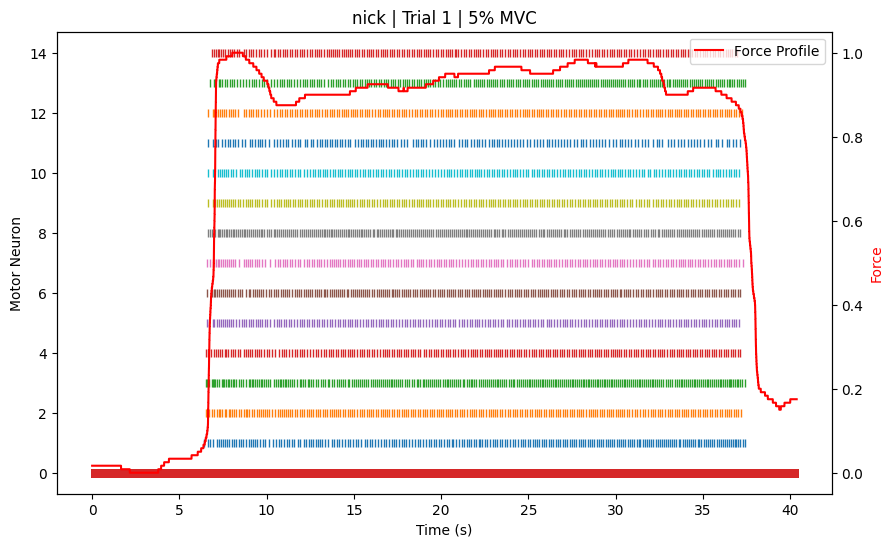

In [103]:
import globals.visualization
importlib.reload(globals.visualization)
from globals.visualization import visualize_trial

visualize_trial(df=df, subject="nick", mvc_level=5, trial_number=1)